In [ ]:
from typing import Tuple
import numpy as np
import matplotlib.pyplot as plt
import torch
import mitsuba as mi
mi.set_variant("cuda_ad_rgb")
from pytorch3d.loss import chamfer_distance
from integrators.PPM import PPMIntegrator
from integrators.Utils import radius_search
import tinycudann as tcnn

In [13]:
device = "cuda"
radius = 6.0
scene = mi.load_file("scenes/dataset_caustics/scene_4.xml")
film: mi.Film = scene.sensors()[0].film()
N = film.size().x * film.size().y
neighbors = 50
sampler_eye = mi.PCG32(size=N, initstate=0)
photons_per_iter = 1000000
sampler = mi.PCG32(size=photons_per_iter, initstate=42)
ppm = PPMIntegrator(photons_per_iter, 1, device=device,init_radius=radius, use_id=False, pure_caustic=True)
radius_data = ppm.initialize_radius(scene, sampler_eye, radius)

In [14]:
gps = ppm.eye_pass(scene, sampler_eye)
photons = ppm.photon_pass(scene, sampler, 0)
photons_data, flux_data, flux_correc_data, n_matches_data, _ = radius_search(photons, gps, radius_data, neighbors, device)

tensor(703, device='cuda:0', dtype=torch.int32)


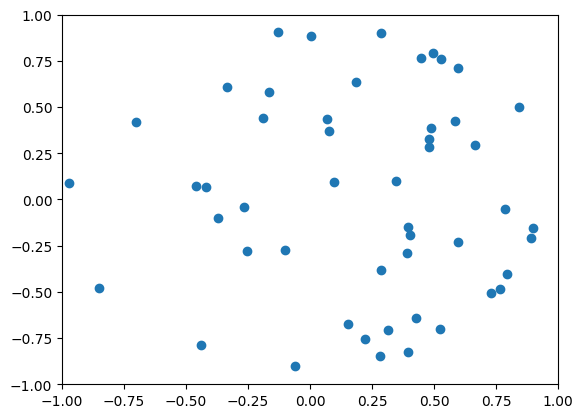

<Figure size 640x480 with 0 Axes>

In [15]:
test_idx = N // 3
print(n_matches_data[test_idx])
plt.scatter(photons_data[test_idx, 0, :].cpu() / radius_data[test_idx].cpu(), photons_data[test_idx, 1, :].cpu() / radius_data[test_idx].cpu())
plt.xlim(-1, 1)
plt.ylim(-1, 1)
plt.show()
plt.clf()

In [ ]:
from integrators.Model import PhotonEncoder

In [17]:
class PhotonDecoder(torch.nn.Module):
    def __init__(self, neighbors: int, dcv_size: int, outchannels: int, use_mask=True, n_hidden_pred: int=3, finalact: str="none"):
        """Base class for the DPM model.
        
        This class is used to define the network architecture and the forward pass.

        Args:
            neighbors (int): number of photons as input
            dcv_size (int): size of the DCV
            dcvaddinonal_dim (int): additional dimension for the DCV for the predictor
            outchannels (int): output dimension of the network (predictor)
            dpm (bool): if True, use Deep Photon Mapping (DPM) architecture, means that the DCV and the photon encoding is passed to the predictor
            n_hidden_pred (int, optional): number of hidden layers for the predictor. Defaults to 3.
            finalact (str, optional): activation function for the final layer. Defaults to "none".
            size (str, optional): size of the network. Defaults to "small".
        """
        super(PhotonDecoder, self).__init__()
        self.neighbors = neighbors
        self.dcv_size = dcv_size
        self.use_mask = use_mask
        
        # Embedder
        config_network = {
            "activation": "Tanh",
            "output_activation": "None",
            "n_neurons": dcv_size,
            "n_hidden_layers": n_hidden_pred,
            "use_bias": True,
            "final_activation": finalact,
        }
        
        self.photon_predictor = tcnn.Network(
            n_input_dims=dcv_size, 
            n_output_dims=outchannels,
            network_config=config_network)


    @torch.autocast(device_type="cuda")
    def forward(self, z) -> torch.Tensor:
        # Tiny-cuda-nn expect the inputs to be (batch * neighbors, input_dim)
        result = self.photon_predictor(z)
        return result

In [18]:
class PhotonVAE(torch.nn.Module):
    def __init__(self, neighbors: int, dcv_size: int, inchannels: int, outchannels: int, use_mask=True, n_hidden_pred: int=3, finalact: str="none"):
        super(PhotonVAE, self).__init__()
        self.neighbors = neighbors
        self.dcv_size = dcv_size
        self.use_mask = use_mask
        self.encoder = PhotonEncoder(neighbors, dcv_size, inchannels, use_mask=use_mask, n_hidden_pred=n_hidden_pred)
        self.decoder = PhotonDecoder(neighbors, dcv_size, outchannels, use_mask=use_mask, n_hidden_pred=n_hidden_pred, finalact=finalact)
        self.inchannels = inchannels
        
        self.mu = torch.nn.Linear(self.dcv_size, self.dcv_size)
        self.logvar = torch.nn.Linear(self.dcv_size, self.dcv_size)
    
    
    def reparameterize(self, mu, logvar, device):
        std = torch.exp(0.5 * logvar)
        
        eps = torch.randn_like(std, device=device)
            
        z = mu + eps * std
        return z

    def forward(self, photons, device, n_match) -> Tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
        dcv, _, mask = self.encoder(photons, device, n_match)
        
        mu = self.mu(dcv.squeeze(-1))
        logvar = self.logvar(dcv.squeeze(-1))
        logvar = torch.clamp(logvar, min=-10.0, max=10.0)
        z = self.reparameterize(mu.unsqueeze(1).repeat(1, neighbors, 1).reshape(-1, self.dcv_size), logvar.unsqueeze(1).repeat(1, neighbors, 1).reshape(-1, self.dcv_size), device)
        
        reconstruct = self.decoder(z).reshape(-1, self.inchannels, self.neighbors)
        result = reconstruct * mask.unsqueeze(1).repeat(1, self.inchannels, 1)
        return result, mu, logvar

In [19]:
dcv_size = 32
inchannels = 2
outchannels = inchannels
n_hidden = 3
final_act = "None"

vae = PhotonVAE(neighbors, dcv_size, inchannels, outchannels, use_mask=True, n_hidden_pred=n_hidden, finalact=final_act).to(device)

tensor([[[-0.2651,  0.1099, -0.0519,  0.4861, -0.2255, -0.1600,  0.5488,
           0.1422, -0.2454,  0.0900, -0.2317, -0.5532,  0.3479,  0.1946,
           0.1340, -0.2200, -0.5361,  0.2808,  0.5146,  0.0362, -0.7119,
           1.0352,  0.1464, -0.0034, -0.4648,  0.5532,  0.1685,  0.1097,
           0.5059,  0.2163, -0.0929, -0.2133,  0.4702,  0.0766, -0.1696,
          -0.1500, -0.3181, -0.5190, -0.3716,  0.3516,  0.1595, -0.1288,
          -0.1467, -1.0420, -0.0264,  0.4712, -0.0672, -0.2188,  0.2603,
          -0.0533],
         [-0.6553,  0.3479,  0.0149,  0.0902, -0.0435, -0.1231,  0.1791,
           0.0231, -0.2303,  0.3472,  0.1587,  0.0178,  0.4763,  0.1228,
          -0.3472,  0.4795,  0.1037, -0.2354, -0.1592, -0.3350, -0.2217,
           0.6836, -0.4185,  0.2803, -0.2834,  0.2920,  0.0229,  0.3137,
           0.1238, -0.7021,  0.1182, -0.1105,  0.0825, -1.2500, -0.1975,
           0.3816, -0.3142,  0.2925, -0.3894, -0.2839,  0.2317,  0.0283,
          -0.3523,  0.3108,  0.

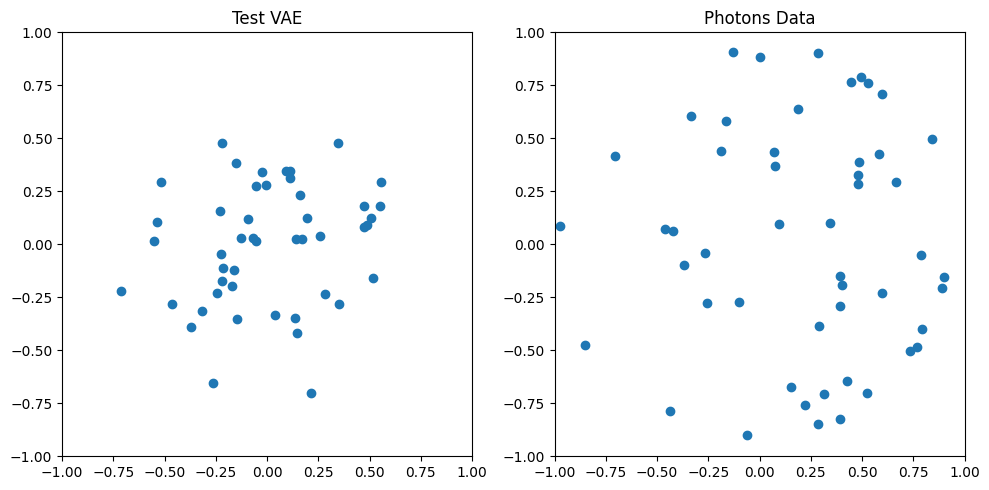

In [20]:
data_test = photons_data[test_idx:test_idx+1, :2, :]
# data_test[:, :, 10:] = 0.0
n_matches_test = n_matches_data[test_idx:test_idx+1]
radius_test = radius_data[test_idx:test_idx+1]
data_test /= radius_test
# n_matches_test[0] = 10

test, _, _ = vae(data_test, device, n_matches_test)
print(test)
fig, axs = plt.subplots(1, 2, figsize=(10, 5))  # 1 row, 2 columns

# First scatter plot
axs[0].scatter(test[0, 0, :].detach().cpu(), test[0, 1, :].detach().cpu())
axs[0].set_xlim(-1, 1)
axs[0].set_ylim(-1, 1)
axs[0].set_title("Test VAE")

# Second scatter plot
axs[1].scatter(
    data_test[0, 0, :].cpu(),
    data_test[0, 1, :].cpu()
)
axs[1].set_xlim(-1, 1)
axs[1].set_ylim(-1, 1)
axs[1].set_title("Photons Data")

plt.tight_layout()
plt.show()

(array([1.117e+03, 2.501e+03, 1.897e+03, 1.454e+03, 1.248e+03, 1.176e+03,
        1.070e+03, 9.330e+02, 8.210e+02, 7.570e+02, 6.570e+02, 6.980e+02,
        7.280e+02, 7.600e+02, 8.010e+02, 8.200e+02, 8.110e+02, 6.780e+02,
        6.620e+02, 5.590e+02, 5.690e+02, 5.580e+02, 5.630e+02, 5.840e+02,
        5.340e+02, 4.960e+02, 4.480e+02, 5.210e+02, 5.120e+02, 5.380e+02,
        4.830e+02, 4.320e+02, 4.430e+02, 3.660e+02, 4.030e+02, 4.870e+02,
        3.810e+02, 3.940e+02, 3.900e+02, 3.880e+02, 3.840e+02, 3.860e+02,
        3.540e+02, 3.440e+02, 3.420e+02, 4.000e+02, 3.260e+02, 3.850e+02,
        4.020e+02, 4.310e+02, 3.800e+02, 3.770e+02, 3.760e+02, 3.410e+02,
        3.710e+02, 3.740e+02, 2.840e+02, 3.050e+02, 3.280e+02, 3.480e+02,
        3.820e+02, 3.470e+02, 3.480e+02, 3.520e+02, 3.190e+02, 2.660e+02,
        2.830e+02, 3.010e+02, 2.430e+02, 2.630e+02, 2.390e+02, 3.160e+02,
        2.140e+02, 2.330e+02, 2.230e+02, 2.540e+02, 2.440e+02, 2.470e+02,
        2.570e+02, 2.490e+02, 2.660e+0

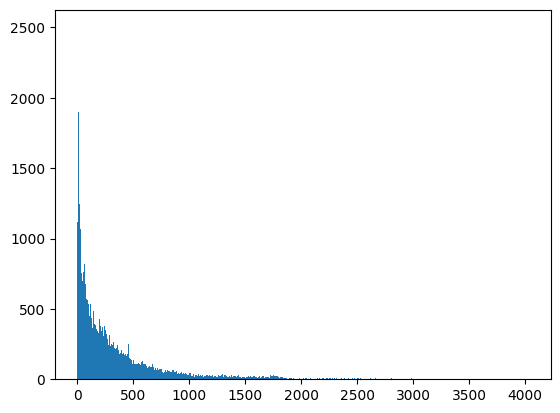

In [21]:
plt.hist(n_matches_data.cpu(), bins=1000)

In [22]:
n_epochs = 300
optimizer = torch.optim.Adam(vae.parameters(), lr=0.0001)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=20, gamma=0.9)
batch_size = 100
n_batch = 100
error = []

for i in range(n_epochs):
    gps = ppm.eye_pass(scene, sampler_eye)
    photons = ppm.photon_pass(scene, sampler, i)
    photons_data, flux_data, flux_correc_data, n_matches_data, _ = radius_search(photons, gps, radius_data, neighbors, device)
    # photons_data = data_test.repeat(N, 1, 1)
    n_matches_data = n_matches_test.repeat(N)
    idx_shuffle = np.random.permutation(N)
    photons_data = photons_data[idx_shuffle, :, :]
    n_matches_data = n_matches_data[idx_shuffle]
    radius_shuffle = radius_data[idx_shuffle]
    mask = n_matches_data >= 2
    photons_data = photons_data[mask]
    n_matches_data = n_matches_data[mask]
    radius_shuffle = radius_shuffle[mask]
    error_batch = []
    
    for b in range(n_batch):
        optimizer.zero_grad()
        start = b * batch_size
        end = (b + 1) * batch_size
        radii = radius_shuffle[start:end].unsqueeze(1).unsqueeze(2)
        photons_batch = photons_data[start:end, :2, :] / radii
        n_matches = n_matches_data[start:end]
        
        pred, mu, logvar = vae(photons_batch, device, n_matches)
        n_matches = torch.clamp(n_matches, 0, neighbors).long()
        chamfer, _ = chamfer_distance(photons_batch.permute(0, 2, 1), pred.permute(0, 2, 1).float(), x_lengths=n_matches, y_lengths=n_matches)
        kl_divergence = torch.mean(-0.5 * torch.sum(1 + logvar - mu ** 2 - logvar.exp(), dim=1), dim=0)
        loss = chamfer #+ 0.01 * kl_divergence
        # print(loss)
        loss.backward()
        optimizer.step()
        error_batch.append(loss.item())
    scheduler.step()
    mean_error = np.mean(error_batch)
    print(f"Error epoch {i} : {mean_error}")
    error.append(mean_error)
        

Error epoch 0 : 0.07613036915659904
Error epoch 1 : 0.07138081684708596
Error epoch 2 : 0.06997468888759613
Error epoch 3 : 0.06925648488104344
Error epoch 4 : 0.0679932389035821
Error epoch 5 : 0.06693536937236785
Error epoch 6 : 0.06635071571916341
Error epoch 7 : 0.06480441674590111
Error epoch 8 : 0.06456465426832438
Error epoch 9 : 0.06310658689588308
Error epoch 10 : 0.062553924433887
Error epoch 11 : 0.06223852802067995
Error epoch 12 : 0.061806371472775935
Error epoch 13 : 0.06097023505717516
Error epoch 14 : 0.059703085646033285
Error epoch 15 : 0.05934501003473997
Error epoch 16 : 0.05820277642458677
Error epoch 17 : 0.057025334909558294
Error epoch 18 : 0.05593426506966352
Error epoch 19 : 0.054957869462668896
Error epoch 20 : 0.053921100534498695
Error epoch 21 : 0.053668248392641546
Error epoch 22 : 0.05320477560162544
Error epoch 23 : 0.05309539690613747
Error epoch 24 : 0.05269255600869656
Error epoch 25 : 0.052265675589442256
Error epoch 26 : 0.05203245189040899
Error e

tensor([[[ 0.1393, -0.2371, -0.5200,  0.1599, -0.6494,  0.6143, -0.0371,
          -0.1285,  0.7114, -0.7632,  0.2212, -0.2098, -0.4707,  0.1005,
           0.4050, -0.4102, -0.1752, -0.0656,  0.7129, -0.7612, -0.2854,
           0.0961,  0.6675, -0.7866, -0.7183,  0.7437,  0.7095, -0.7539,
           0.3416, -0.4268, -0.4138,  0.0676,  0.6743, -0.7798,  0.1903,
          -0.2037,  0.6162, -0.7817, -0.7183,  0.7212,  0.6753, -0.7837,
          -0.0764, -0.1487, -0.6797,  0.7817,  0.6558, -0.7822, -0.4253,
           0.0391],
         [-0.5801,  0.2340, -0.3025, -0.0647, -0.2365, -0.0806, -0.4011,
           0.1299, -0.1589, -0.1342,  0.4854, -0.7236,  0.0064, -0.2876,
          -0.5532,  0.1841, -0.2325, -0.1132, -0.6133,  0.3958,  0.3726,
          -0.5439,  0.6123, -0.7134, -0.4668,  0.0959,  0.4294, -0.3601,
          -0.4465,  0.0517,  0.3833, -0.5610, -0.3684,  0.0242, -0.6016,
           0.2334, -0.0665, -0.1735, -0.6797,  0.6680, -0.7153,  0.7427,
          -0.6494,  0.5361,  0.

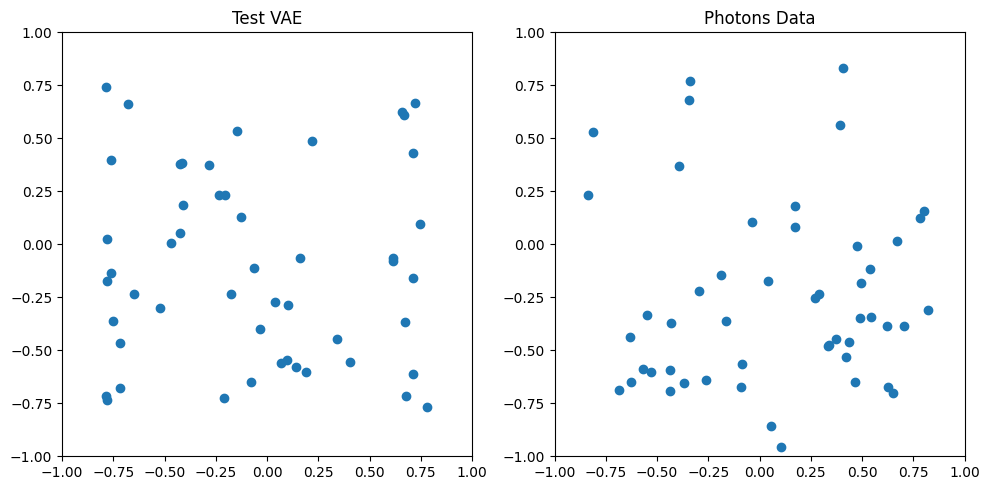

In [23]:
test_idx = np.random.randint(N)
data_test = photons_data[test_idx:test_idx+1, :2, :]
# data_test[:, :, 10:] = 0.0
n_matches_test = n_matches_data[test_idx:test_idx+1]
radius_test = radius_data[test_idx:test_idx+1]
data_test /= radius_test

test, _, _ = vae(data_test, device, n_matches_test)
print(test)
fig, axs = plt.subplots(1, 2, figsize=(10, 5))  # 1 row, 2 columns

# First scatter plot
axs[0].scatter(test[0, 0, :].detach().cpu(), test[0, 1, :].detach().cpu())
axs[0].set_xlim(-1, 1)
axs[0].set_ylim(-1, 1)
axs[0].set_title("Test VAE")

# Second scatter plot
axs[1].scatter(
    data_test[:, 0, :].cpu(),
    data_test[:, 1, :].cpu()
)
axs[1].set_xlim(-1, 1)
axs[1].set_ylim(-1, 1)
axs[1].set_title("Photons Data")

plt.tight_layout()
plt.show()


In [24]:
import os.path
torch.save(vae.encoder.state_dict(), os.path.join("output/training_pretrain_encoder_32/", f"encoder.pth"))